# Enhanced Federated Fine-Tuning of Phi-4 Using OpenFL with PEFT & Quantization

In this tutorial, we demonstrate how to fine-tune Microsoft's Phi-4 model in a federated learning workflow with enhanced local training using:
- Parameter-Efficient Fine-Tuning (PEFT)
- 4-bit Quantization (QLoRA)
- Gradient Checkpointing
- Optimized Training Configuration

## Installation

In [1]:
!pip install torch transformers peft datasets trl==0.12.2 bitsandbytes accelerate -q

In [2]:
!nvidia-smi

Fri May 16 07:23:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000001:00:00.0 Off |                    0 |
| N/A   41C    P0             66W /  400W |       1MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Import Libraries

In [3]:
import os
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel
)
from peft.utils import get_peft_model_state_dict, set_peft_model_state_dict  # Added this import
from datasets import load_dataset
from trl import SFTTrainer
from openfl.experimental.workflow.interface import Aggregator, Collaborator, FLSpec
from openfl.experimental.workflow.placement import aggregator, collaborator
from openfl.experimental.workflow.runtime import LocalRuntime
import numpy as np
from transformers.trainer_callback import PrinterCallback
import transformers
import gc
import psutil

/home/azureuser/env_name/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-16 07:23:13,756	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
# Memory optimization setup
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # Enable dynamic memory allocation
os.environ["TRANSFORMERS_ATTN_IMPLEMENTATION"] = "flash_attention_2"  # Use optimized attention

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

## Acquiring and preprocessing dataset

We can download the dataset directly from the [LLM-Adapters repository](https://github.com/AGI-Edgerunners/LLM-Adapters)

In [ ]:
# Import libraries needed for downloading and verifying the dataset
import hashlib
import requests

def file_checksum(file_path, algorithm="sha256"):
    """
    Calculate the checksum of a file using the specified hashing algorithm.
    
    Args:
        file_path (str): The path to the file for which the checksum is to be calculated.
        algorithm (str): The hashing algorithm to use (default is 'sha256').
    
    Returns:
        str: The calculated checksum of the file.
    """
    hash_func = hashlib.new(algorithm)
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_func.update(chunk)
    return hash_func.hexdigest()


# Download the dataset if it doesn't exist locally
if not os.path.exists("math_10k.json"):
    print("Downloading math_10k.json dataset...")
    r = requests.get(
        "https://raw.githubusercontent.com/AGI-Edgerunners/LLM-Adapters/main/ft-training_set/math_10k.json",
    )
    with open(
        "math_10k.json",
        "wb",
    ) as f:
        f.write(r.content)
    print("Download complete.")

    # Verify the integrity of the downloaded file
    actual_checksum = file_checksum("math_10k.json")
    expected_checksum = "0342d0d860ad8592b579329337c90e42eefd3d9f2898043140cbd120630418b8"
    if actual_checksum != expected_checksum:
        raise ValueError(
            "Checksum verification failed. The file may have been altered."
        )
    print("Checksum verification successful.")
else:
    print("Dataset already exists locally.")

# Set the dataset path to be used later
dataset_name = "math_10k.json"

## Configuration

In [ ]:
# Model and dataset
model_name = "microsoft/phi-4"
#dataset_name = "math_10k.json"

# 4-bit QLoRA configuration
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

# 8-bit QLoRA configuration
bnb_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_skip_modules=['lm_head'],
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False,
)

# Active quantization config (will be set to either 4-bit or 8-bit)
bnb_config = bnb_config_4bit  # Default to 4-bit

# LoRA configuration
peft_config = LoraConfig(
    r=8,  # Increased from original for better adaptation
    lora_alpha=16,
    lora_dropout=0.01,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

# Training configuration
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=2,  # Reduced for Phi-4
    gradient_accumulation_steps=2,
    optim="adamw_torch_fused",
    save_steps=100,
    logging_steps=10,
    learning_rate=3e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.5,
    warmup_ratio=0.02,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    report_to="none"
)

## Load and Prepare Model

In [6]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# Apply LoRA
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Loading checkpoint shards: 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]


trainable params: 27,852,800 || all params: 14,687,360,000 || trainable%: 0.1896


## Load and Prepare Dataset

In [ ]:
def format_prompt(example):
    """
    Format the input example into a standardized prompt structure for training.
    
    This function creates a consistent instruction-response format for the LLM training:
    - Includes instruction, optional input, and expected output
    - Using a standardized template inspired by instruction-tuning datasets
    
    Parameters:
        example (dict): Dictionary containing 'instruction', 'input' (optional), and 'output' fields
    
    Returns:
        str: Formatted prompt with consistent structure for model training and evaluation
    """
    # Handle case where input is provided
    if example["input"]:
        # Format with both instruction and input fields
        return f"""Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{example['instruction']}

### Input:
{example['input']}

### Response:
{example['output']}"""
    else:
        # Format with only instruction (no input field)
        return f"""Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{example['instruction']}

### Response:
{example['output']}"""

# Load dataset
dataset = load_dataset("json", data_files=dataset_name, split="train", num_proc=4)
# Apply formatting to each example in the dataset
dataset = dataset.map(lambda x: {"text": format_prompt(x)}, num_proc=4)

# Split dataset into training and evaluation subsets
dataset = dataset.train_test_split(test_size=0.1)
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

## Enhanced Training with SFTTrainer

In [8]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=1024,
    tokenizer=tokenizer,
    args=training_args,
    packing=True,
)

/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg

## Federated Averaging Function

In [9]:
def FedAvg(peft_params, model, weights=None):
    """
    Perform Federated Averaging (FedAvg) on the model parameters.

    Parameters:
    peft_params (list): A list of state dictionaries containing the model parameters from different clients.
    model (torch.nn.Module): The model to which the averaged parameters will be applied.
    weights (list, optional): A list of weights for averaging the parameters. If None, equal weights are used.

    Returns:
    torch.nn.Module: The model with the averaged parameters applied.
    """
    state_dicts = peft_params
    state_dict = get_peft_model_state_dict(model)
    for key in peft_params[0]:
        dtype = state_dicts[0][key].dtype
        state_dict[key] = torch.from_numpy(
            np.average(
                [state[key].cpu().to(torch.float).numpy() for state in state_dicts], axis=0, weights=weights
            )
        ).to(dtype)
    set_peft_model_state_dict(model, state_dict)
    return model

## Federated Learning Workflow

In [ ]:
# Import the required PrinterCallback for proper initialization/removal
from transformers.trainer_callback import PrinterCallback
import transformers
import gc
import psutil

def get_gpu_memory_info():
    """Get detailed GPU memory usage information in megabytes.
    
    This function checks for CUDA availability and returns a dictionary with memory allocation
    information including allocated, reserved, and maximum allocated GPU memory.
    
    Returns:
        dict: Dictionary with memory usage information in MB:
            - allocated: Currently allocated memory by PyTorch tensors
            - reserved: Total memory reserved by PyTorch
            - max_allocated: Maximum allocated memory since last reset
    
    Note:
        Returns zeros for all metrics if CUDA is not available or if an error occurs.
    """
    try:
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / (1024 * 1024)
            reserved = torch.cuda.memory_reserved() / (1024 * 1024)
            max_allocated = torch.cuda.max_memory_allocated() / (1024 * 1024)
            return {
                "allocated": allocated,
                "reserved": reserved,
                "max_allocated": max_allocated
            }
        else:
            return {"allocated": 0, "reserved": 0, "max_allocated": 0}
    except:
        return {"allocated": 0, "reserved": 0, "max_allocated": 0}

class MemoryTracker:
    """Track GPU memory usage during training"""
    def __init__(self, collaborator_name, quant_type):
        self.collaborator_name = collaborator_name
        self.quant_type = quant_type
        self.timestamps = {}
        self.peak = {"allocated": 0, "reserved": 0, "max_allocated": 0}
        self.training_loss = None
        self.eval_loss = None
        
    def log(self, timestamp):
        """Log current memory usage at a specific timestamp"""
        self.timestamps[timestamp] = get_gpu_memory_info()
        
    def log_loss(self, training_loss=None, eval_loss=None):
        """Log training or evaluation loss"""
        if training_loss is not None:
            self.training_loss = training_loss
        if eval_loss is not None:
            self.eval_loss = eval_loss
            
    def update_peak(self):
        """Update peak memory usage values"""
        current = get_gpu_memory_info()
        self.peak["allocated"] = max(self.peak["allocated"], current["allocated"])
        self.peak["reserved"] = max(self.peak["reserved"], current["reserved"])
        self.peak["max_allocated"] = max(self.peak["max_allocated"], current["max_allocated"])
        
    def reset_peak(self):
        """Reset peak memory usage values"""
        self.peak = {"allocated": 0, "reserved": 0, "max_allocated": 0}
        
    def report(self):
        """Print memory usage report"""
        print(f"\n==== Memory Usage Report for {self.collaborator_name} ({self.quant_type}) ====")
        print(f"Peak Memory Usage:")
        print(f"  Allocated: {self.peak['allocated']:.2f} MB")
        print(f"  Reserved: {self.peak['reserved']:.2f} MB")
        print(f"  Max Allocated: {self.peak['max_allocated']:.2f} MB")
        
        print("\nMemory Usage by Stage:")
        for timestamp, mem in self.timestamps.items():
            print(f"  {timestamp}:")
            print(f"    Allocated: {mem['allocated']:.2f} MB")
            print(f"    Reserved: {mem['reserved']:.2f} MB")
            print(f"    Max Allocated: {mem['max_allocated']:.2f} MB")
        
        print("\nPerformance Metrics:")
        if self.training_loss is not None:
            print(f"  Training Loss: {self.training_loss:.4f}")
        if self.eval_loss is not None:
            print(f"  Evaluation Loss: {self.eval_loss:.4f}")
        print("-" * 50)
        
    def get_stats(self):
        """Get all statistics as a dictionary"""
        stats = {
            "peak_allocated": self.peak["allocated"],
            "peak_reserved": self.peak["reserved"],
            "peak_max_allocated": self.peak["max_allocated"],
            "quant_type": self.quant_type,
            "training_loss": self.training_loss,
            "eval_loss": self.eval_loss
        }
        for timestamp, mem in self.timestamps.items():
            stats[f"{timestamp}_allocated"] = mem["allocated"]
            stats[f"{timestamp}_reserved"] = mem["reserved"]
            stats[f"{timestamp}_max_allocated"] = mem["max_allocated"]
        return stats

def plot_memory_metrics(flow_4bit, flow_8bit):
    """Plot and compare memory metrics between 4-bit and 8-bit quantization."""
    try:
        import matplotlib.pyplot as plt
        import pandas as pd
        from matplotlib.ticker import EngFormatter

        # Create figure with multiple subplots
        fig, axs = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('4-bit vs 8-bit Quantization Comparison', fontsize=16)
        
        # Colors for consistent plotting
        colors_4bit = {'Portland': 'blue', 'Seattle': 'green'}
        colors_8bit = {'Portland': 'darkblue', 'Seattle': 'darkgreen'}
        markers_4bit = {'Portland': 'o', 'Seattle': 's'}
        markers_8bit = {'Portland': '^', 'Seattle': 'D'}
        
        # Flatten the metric data for plotting
        memory_data = []
        for quant, flow in [("4-bit", flow_4bit), ("8-bit", flow_8bit)]:
            stats = flow.all_memory_stats
            for collab, rounds_data in stats.items():
                for round_name, metrics in rounds_data.items():
                    round_num = int(round_name.split('_')[1])
                    row = {
                        'Collaborator': collab,
                        'Round': round_num,
                        'Quantization': quant,
                        'Peak Memory (MB)': metrics.get('peak_max_allocated', 0),
                        'Training Loss': metrics.get('training_loss', 0),
                        'Eval Loss': metrics.get('eval_loss', 0)
                    }
                    memory_data.append(row)
        
        df = pd.DataFrame(memory_data)
        
        # Plot 1: Peak Memory Usage by Round
        axs[0, 0].set_title('Peak Memory Usage by Round')
        for quant_type in ['4-bit', '8-bit']:
            for collab in df['Collaborator'].unique():
                subset = df[(df['Quantization'] == quant_type) & (df['Collaborator'] == collab)]
                color = colors_4bit[collab] if quant_type == '4-bit' else colors_8bit[collab]
                marker = markers_4bit[collab] if quant_type == '4-bit' else markers_8bit[collab]
                axs[0, 0].plot(subset['Round'], subset['Peak Memory (MB)'], 
                              marker=marker, linestyle='-', label=f"{collab} ({quant_type})",
                              color=color)
        
        axs[0, 0].set_xlabel('Round')
        axs[0, 0].set_ylabel('Memory (MB)')
        axs[0, 0].legend()
        axs[0, 0].grid(True, alpha=0.3)
        axs[0, 0].yaxis.set_major_formatter(EngFormatter(unit='B'))
        
        # Plot 2: Training Loss by Round
        axs[0, 1].set_title('Training Loss by Round')
        for quant_type in ['4-bit', '8-bit']:
            for collab in df['Collaborator'].unique():
                subset = df[(df['Quantization'] == quant_type) & (df['Collaborator'] == collab)]
                color = colors_4bit[collab] if quant_type == '4-bit' else colors_8bit[collab]
                marker = markers_4bit[collab] if quant_type == '4-bit' else markers_8bit[collab]
                axs[0, 1].plot(subset['Round'], subset['Training Loss'], 
                              marker=marker, linestyle='-', label=f"{collab} ({quant_type})",
                              color=color)
        
        axs[0, 1].set_xlabel('Round')
        axs[0, 1].set_ylabel('Loss')
        axs[0, 1].legend()
        axs[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: Eval Loss by Round
        axs[1, 0].set_title('Evaluation Loss by Round')
        for quant_type in ['4-bit', '8-bit']:
            for collab in df['Collaborator'].unique():
                subset = df[(df['Quantization'] == quant_type) & (df['Collaborator'] == collab)]
                color = colors_4bit[collab] if quant_type == '4-bit' else colors_8bit[collab]
                marker = markers_4bit[collab] if quant_type == '4-bit' else markers_8bit[collab]
                axs[1, 0].plot(subset['Round'], subset['Eval Loss'], 
                              marker=marker, linestyle='-', label=f"{collab} ({quant_type})",
                              color=color)
        
        axs[1, 0].set_xlabel('Round')
        axs[1, 0].set_ylabel('Loss')
        axs[1, 0].legend()
        axs[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: Memory vs Loss (bubble chart)
        axs[1, 1].set_title('Memory Usage vs. Evaluation Loss')
        for quant_type in ['4-bit', '8-bit']:
            for collab in df['Collaborator'].unique():
                subset = df[(df['Quantization'] == quant_type) & (df['Collaborator'] == collab)]
                color = colors_4bit[collab] if quant_type == '4-bit' else colors_8bit[collab]
                marker = markers_4bit[collab] if quant_type == '4-bit' else markers_8bit[collab]
                
                # Size proportional to round number for visual differentiation
                sizes = [100 * (r+1) for r in subset['Round']]
                
                axs[1, 1].scatter(subset['Peak Memory (MB)'], subset['Eval Loss'],
                                 s=sizes, alpha=0.7, 
                                 label=f"{collab} ({quant_type})",
                                 color=color, marker=marker)
                
                # Add round number annotations
                for _, row in subset.iterrows():
                    axs[1, 1].annotate(f"R{int(row['Round'])}", 
                                      (row['Peak Memory (MB)'], row['Eval Loss']),
                                      xytext=(5, 5), textcoords='offset points')
        
        axs[1, 1].set_xlabel('Peak Memory (MB)')
        axs[1, 1].set_ylabel('Evaluation Loss')
        axs[1, 1].legend()
        axs[1, 1].grid(True, alpha=0.3)
        axs[1, 1].xaxis.set_major_formatter(EngFormatter(unit='B'))
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()
        
        # Print summary comparison
        print("\n==== Performance Summary ====\n")
        # Group by quantization and compute means
        summary = df.groupby('Quantization').agg({
            'Peak Memory (MB)': 'mean',
            'Training Loss': 'mean', 
            'Eval Loss': 'mean'
        }).reset_index()
        
        # Calculate percentage difference
        mem_diff_pct = ((summary.loc[1, 'Peak Memory (MB)'] - summary.loc[0, 'Peak Memory (MB)']) / 
                       summary.loc[0, 'Peak Memory (MB)'] * 100)
        
        eval_diff_pct = ((summary.loc[1, 'Eval Loss'] - summary.loc[0, 'Eval Loss']) / 
                        summary.loc[0, 'Eval Loss'] * 100)
        
        print(f"Memory Usage Comparison:")
        print(f"  4-bit Avg: {summary.loc[0, 'Peak Memory (MB)']:.2f} MB")
        print(f"  8-bit Avg: {summary.loc[1, 'Peak Memory (MB)']:.2f} MB")
        print(f"  Difference: {abs(mem_diff_pct):.1f}% {'more' if mem_diff_pct > 0 else 'less'} memory with 8-bit")
        
        print(f"\nEvaluation Loss Comparison:")
        print(f"  4-bit Avg: {summary.loc[0, 'Eval Loss']:.4f}")
        print(f"  8-bit Avg: {summary.loc[1, 'Eval Loss']:.4f}")
        print(f"  Difference: {abs(eval_diff_pct):.1f}% {'higher' if eval_diff_pct > 0 else 'lower'} loss with 8-bit")
        
        loss_efficiency = ((summary.loc[0, 'Eval Loss'] - summary.loc[1, 'Eval Loss']) / 
                          (summary.loc[0, 'Peak Memory (MB)'] - summary.loc[1, 'Peak Memory (MB)']))
        
        if loss_efficiency > 0:
            efficiency_msg = "8-bit provides better memory efficiency with lower loss"
        else:
            efficiency_msg = "4-bit provides better memory efficiency with lower loss"
            
        print(f"\nEfficiency Analysis: {efficiency_msg}")
    except ImportError:
        print("Plotting requires matplotlib and pandas. Install with: pip install matplotlib pandas")
    except Exception as e:
        print(f"Error plotting metrics: {str(e)}")

class FederatedFlow(FLSpec):
    def __init__(self, model=None, optimizer=None, rounds=3, quant_type="4bit", **kwargs):
        """
        Initialize the class with the given model, optimizer, and number of rounds.

        Parameters:
        model (torch.nn.Module, optional): The model to be used. If None, a ValueError is raised.
        optimizer (torch.optim.Optimizer, optional): The optimizer to be used.
        rounds (int, optional): The number of rounds for training or processing (default is 3).
        quant_type (str, optional): Quantization type, either "4bit" or "8bit".
        **kwargs: Additional keyword arguments to be passed to the superclass initializer.

        Raises:
        ValueError: If no model is provided.
        """
        super().__init__(**kwargs)
        if model is not None:
            self.model = model
            self.peft_params = get_peft_model_state_dict(self.model)
            self.optimizer = optimizer
        else:
            raise ValueError("No model inputted")

        self.rounds = rounds
        self.quant_type = quant_type
        # Initialize histories for tracking metrics over rounds
        self.average_loss_history = []
        self.agg_model_loss_history = []
        self.local_model_loss_history = []
        

    @aggregator
    def start(self):
        """
        Initialize the model and set up the collaborators for federated learning.

        This method performs the initial setup for the model, including setting the
        collaborators, initializing private variables, and starting the first round
        of the federated learning process.
        """
        print(f"Performing initialization for model with {self.quant_type} quantization")
        self.collaborators = self.runtime.collaborators
        self.current_round = 0
        # Initialize dictionary to collect memory stats
        # Check if collaborators are objects with name attribute or strings
        if hasattr(self.collaborators[0], 'name'):
            collab_names = [c.name for c in self.collaborators]
        else:
            # If collaborators are already strings, use them directly
            collab_names = self.collaborators
        self.all_memory_stats = {collab: {} for collab in collab_names}
        self.next(
            self.aggregated_model_validation,
            foreach="collaborators",
        )

    
    @collaborator
    def aggregated_model_validation(self):
        """
        Perform aggregated model validation for a collaborator.

        This method loads the model, applies the PEFT configuration, and evaluates
        the model using the provided training and evaluation datasets. The validation
        score is then stored and the next step in the process is triggered.
        """
        print(f"Performing aggregated model validation for collaborator {self.input} with {self.quant_type}")
        # Initialize memory tracker for this collaborator
        self.memory_tracker = MemoryTracker(self.input, self.quant_type)
        self.memory_tracker.reset_peak()
        
        # Choose quantization config based on quant_type
        if self.quant_type == "4bit":
            quant_config = bnb_config_4bit
        else:  # 8bit
            quant_config = bnb_config_8bit
        
        # Define device_map variable
        #device_map = "auto"
        device_map = {"": torch.cuda.current_device()} if torch.cuda.is_available() else "cpu"
        try:
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                quantization_config=quant_config,
                device_map=device_map,
                trust_remote_code=True
            )
            self.memory_tracker.log("model_load")
        except ValueError:
            # Fallback to CPU if GPU memory is insufficient
            print(f"Falling back to CPU mode for {self.input}")
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                device_map="cpu",
                trust_remote_code=True
            )
            self.memory_tracker.log("model_load")
        
        self.model = prepare_model_for_kbit_training(self.model)
        self.model = get_peft_model(self.model, peft_config)
        set_peft_model_state_dict(self.model, self.peft_params)
        
        trainer = SFTTrainer(
            model=self.model,
            args=training_args,
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=1024,
            dataset_text_field="text",
            tokenizer=tokenizer,
            packing=True,
            data_collator=transformers.DataCollatorForSeq2Seq(
                tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            ),
        )

        trainer.remove_callback(PrinterCallback)
        out = trainer.evaluate()
        self.agg_validation_score = out["eval_loss"]
        print(f"{self.input} value of {self.agg_validation_score}")
        self.memory_tracker.log_loss(eval_loss=self.agg_validation_score)  # Log eval loss
        self.memory_tracker.update_peak()
        self.next(self.train)

    @collaborator
    def train(self):
        """
        Train the model for a collaborator.

        This method trains the model using the provided training and evaluation datasets.
        The training loss is stored, the model is saved, and the next step in the process
        is triggered.
        """
        self.memory_tracker.log("before_training")
        trainer = SFTTrainer(
            model=self.model,
            args=training_args,
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=1024,
            dataset_text_field="text",
            tokenizer=tokenizer,
            packing=True,
            data_collator=transformers.DataCollatorForSeq2Seq(
                tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            ),
        )

        out = trainer.train()
        self.loss = out.training_loss
        self.memory_tracker.log("after_training")
        self.memory_tracker.log_loss(training_loss=self.loss)  # Log training loss
        self.memory_tracker.update_peak()
        trainer.save_model()
        self.training_completed = True
        self.next(self.local_model_validation)

    @collaborator
    def local_model_validation(self):
        """
        Perform local model validation for a collaborator.

        This method evaluates the model using the provided training and evaluation datasets.
        The validation score is stored, the PEFT parameters are updated, and the next step
        in the process is triggered.
        """
        trainer = SFTTrainer(
            model=self.model,
            args=training_args,
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=1024,
            dataset_text_field="text",
            tokenizer=tokenizer,
            packing=True,
            data_collator=transformers.DataCollatorForSeq2Seq(
                tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            ),
        )
        out = trainer.evaluate()
        self.local_validation_score = out["eval_loss"]
        self.memory_tracker.log_loss(eval_loss=self.local_validation_score)  # Log eval loss
        self.peft_params = get_peft_model_state_dict(self.model)
        print(f"Doing local model validation for collaborator {self.input}")
        
        # Display memory report for this collaborator
        self.memory_tracker.report()
        self.memory_stats = self.memory_tracker.get_stats()
        self.next(self.join, exclude=["training_completed", "model", "memory_tracker"])

    @aggregator
    def join(self, inputs):
        """
        Aggregate the results from all collaborators and update the model.

        This method calculates the average loss, aggregated model accuracy, and local model
        accuracy from all collaborators. The model parameters are updated using Federated
        Averaging (FedAvg), and the next round of the process is triggered if applicable.
        """
        self.average_loss = sum(input.loss for input in inputs) / len(inputs)
        self.aggregated_model_accuracy = sum(
            input.agg_validation_score for input in inputs
        ) / len(inputs)
        self.local_model_accuracy = sum(
            input.local_validation_score for input in inputs
        ) / len(inputs)
        print(
            f"Average aggregated model validation values = {self.aggregated_model_accuracy}"
        )
        print(f"Average training loss = {self.average_loss}")
        print(f"Average local model validation values = {self.local_model_accuracy}")

        # Store metrics in history for plotting trends
        self.average_loss_history.append(self.average_loss)
        self.agg_model_loss_history.append(self.aggregated_model_accuracy)
        self.local_model_loss_history.append(self.local_model_accuracy)
        
        # Collect memory stats from all collaborators for this round
        for input_data in inputs:
            self.all_memory_stats[input_data.input][f"round_{self.current_round}"] = input_data.memory_stats

        self.model = FedAvg([input.peft_params for input in inputs], self.model)
        self.peft_params = get_peft_model_state_dict(self.model)

        self.model.save_pretrained("./aggregated/model")
        tokenizer.save_pretrained("./aggregated/tokenizer")
        self.current_round += 1
        if self.current_round < self.rounds:
            self.next(
                self.aggregated_model_validation,
                foreach="collaborators",
                exclude=["model"],
            )
        else:
            self.next(self.end)

    @aggregator
    def end(self):
        """
        End the federated learning process.

        This method marks the end of the federated learning process and performs any
        necessary cleanup or finalization steps.
        """
        print(f"This is the end of the flow for {self.quant_type} quantization")
        print("\n===== Final Metrics =====\n")
        print(f"Average Training Loss: {self.average_loss_history[-1]:.4f}")
        print(f"Final Aggregated Model Loss: {self.agg_model_loss_history[-1]:.4f}")
        print(f"Final Local Model Loss: {self.local_model_loss_history[-1]:.4f}")
        
        print("\n===== Memory Usage Summary Across All Rounds =====\n")
        
        # Print aggregated memory statistics
        for collab, rounds_data in self.all_memory_stats.items():
            print(f"\n==== {collab} Memory Usage Across Rounds ({self.quant_type}) ====\n")
            for round_name, stats in rounds_data.items():
                print(f"  {round_name}:")
                for metric, value in stats.items():
                    if value is not None:
                        if metric in ['training_loss', 'eval_loss', 'quant_type']:
                            if metric != 'quant_type':
                                print(f"    {metric}: {value:.4f}")
                        else:
                            print(f"    {metric}: {value:.2f} MB")
                    else:
                        print(f"    {metric}: Not recorded")
            print("-" * 50)

Aggregator step "start" registered
Collaborator step "aggregated_model_validation" registered
Collaborator step "train" registered
Collaborator step "local_model_validation" registered
Aggregator step "join" registered
Aggregator step "end" registered


## Run Federated Learning with 4-bit and 8-bit Quantization

In [11]:
# Setup participants
aggregator = Aggregator()
collaborators = [
    Collaborator(name="Portland"),
    Collaborator(name="Seattle")
]

# Assign data shards
for idx, colab in enumerate(collaborators):
    colab.private_attributes = {
        "train_dataset": train_dataset.shard(len(collaborators), idx),
        "eval_dataset": eval_dataset.shard(len(collaborators), idx)
    }

# First run with 4-bit quantization
print("\n=============== Running with 4-bit Quantization ===============\n")
bnb_config = bnb_config_4bit  # Set active config to 4-bit
runtime = LocalRuntime(aggregator=aggregator, collaborators=collaborators)
flflow_4bit = FederatedFlow(model, rounds=2, quant_type="4bit")
flflow_4bit.runtime = runtime
flflow_4bit.run()

# Clean up CUDA cache between runs
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Cleared CUDA cache between runs")

# Then run with 8-bit quantization
print("\n=============== Running with 8-bit Quantization ===============\n")
bnb_config = bnb_config_8bit  # Set active config to 8-bit
# Reload the model with 8-bit quantization
model_8bit = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config_8bit,
    device_map="auto",
    trust_remote_code=True
)
model_8bit = prepare_model_for_kbit_training(model_8bit)
model_8bit = get_peft_model(model_8bit, peft_config)

runtime = LocalRuntime(aggregator=aggregator, collaborators=collaborators)
flflow_8bit = FederatedFlow(model_8bit, rounds=2, quant_type="8bit")
flflow_8bit.runtime = runtime
flflow_8bit.run()


=============== Running with 4-bit Quantization ===============


Calling start
Performing initialization for model with 4bit quantization

Calling aggregated_model_validation
Performing aggregated model validation for collaborator Portland with 4bit


Loading checkpoint shards: 100%|##########| 6/6 [00:04<00:00,  1.27it/s]
/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/train

Portland value of 0.5819987058639526

Calling train


/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg

Step,Training Loss
10,0.501600
20,0.373200
30,0.337300
40,0.348300
50,0.334300
60,0.331800
70,0.322600
80,0.325800
90,0.320700
100,0.328900


...

Step,Training Loss
10,0.294400
20,0.284700
30,0.289000
40,0.282800
50,0.279500
60,0.277900
70,0.289600
80,0.294600
90,0.275700
100,0.276200


/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: i


Calling local_model_validation


/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg

Doing local model validation for collaborator Seattle

==== Memory Usage Report for Seattle (8bit) ====
Peak Memory Usage:
  Allocated: 75529.57 MB
  Reserved: 93476.00 MB
  Max Allocated: 92767.32 MB

Memory Usage by Stage:
  model_load:
    Allocated: 73023.56 MB
    Reserved: 74242.00 MB
    Max Allocated: 92767.32 MB
  before_training:
    Allocated: 75388.56 MB
    Reserved: 93476.00 MB
    Max Allocated: 92767.32 MB
  after_training:
    Allocated: 75529.57 MB
    Reserved: 83044.00 MB
    Max Allocated: 92767.32 MB

Performance Metrics:
  Training Loss: 0.2912
  Evaluation Loss: 0.3080
--------------------------------------------------
Should transfer from local_model_validation to join

Calling join
Average aggregated model validation values = 0.30404751002788544
Average training loss = 0.29131152119699005
Average local model validation values = 0.3009362369775772

Calling end
This is the end of the flow for 8bit quantization

===== Final Metrics =====

Average Training Loss: 0

## Compare VRAM Usage and Training Loss Between 4-bit and 8-bit


==== Memory Usage Comparison: 4-bit vs 8-bit ====



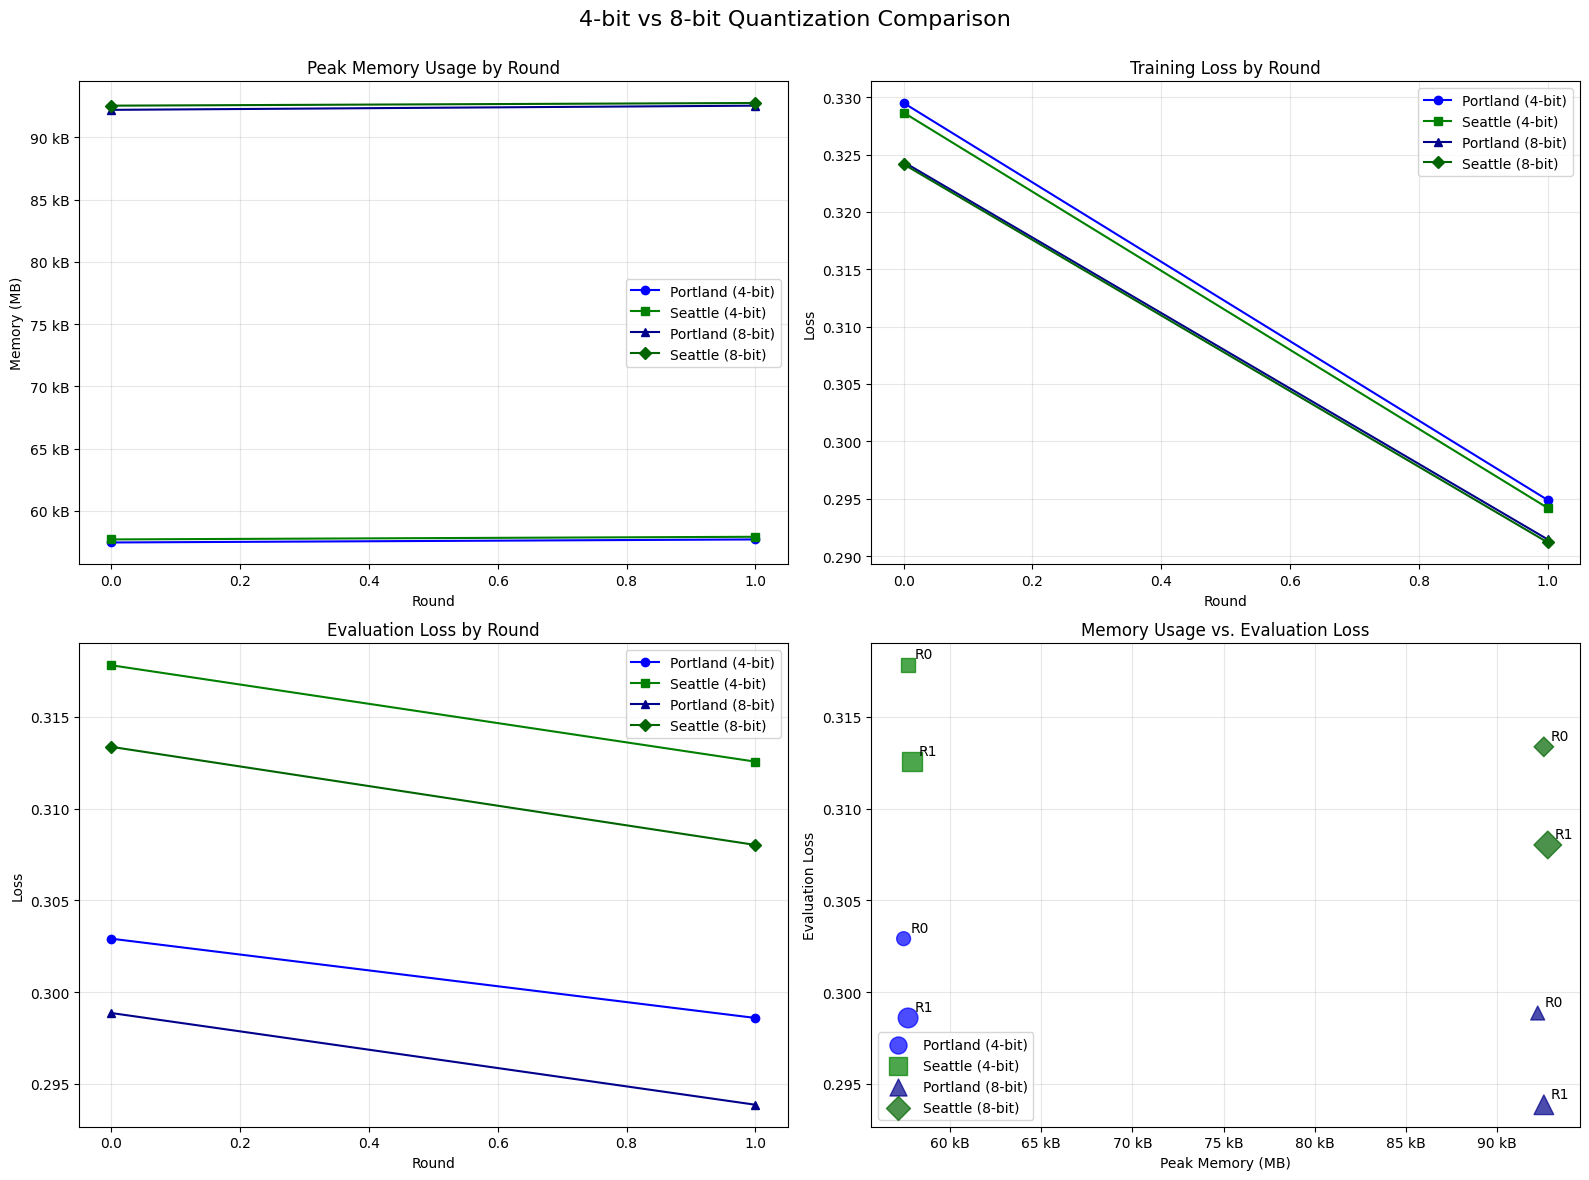


==== Performance Summary ====

Memory Usage Comparison:
  4-bit Avg: 57698.24 MB
  8-bit Avg: 92521.30 MB
  Difference: 60.4% more memory with 8-bit

Evaluation Loss Comparison:
  4-bit Avg: 0.3080
  8-bit Avg: 0.3035
  Difference: 1.4% lower loss with 8-bit

Efficiency Analysis: 4-bit provides better memory efficiency with lower loss


In [12]:
# Plot memory metrics comparison between 4-bit and 8-bit
print("\n==== Memory Usage Comparison: 4-bit vs 8-bit ====\n")
plot_memory_metrics(flflow_4bit, flflow_8bit)

## Analysis and Conclusions

In [14]:
# Utility functions to monitor GPU memory usage
def get_gpu_memory_info():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        # Get the current device
        device = torch.cuda.current_device()
        # Get memory information
        total_memory = torch.cuda.get_device_properties(device).total_memory / 1024**2  # MB
        allocated_memory = torch.cuda.memory_allocated(device) / 1024**2  # MB
        reserved_memory = torch.cuda.memory_reserved(device) / 1024**2  # MB
        free_memory = total_memory - allocated_memory
        
        return {
            "device": device,
            "total_memory_mb": total_memory,
            "allocated_memory_mb": allocated_memory,
            "reserved_memory_mb": reserved_memory,
            "free_memory_mb": free_memory
        }
    else:
        return {"device": "cpu", "error": "CUDA not available"}

class MemoryTracker:
    """Track memory usage across training phases"""
    def __init__(self, collaborator_name, quant_type="4bit"):
        self.collaborator_name = collaborator_name
        self.quant_type = quant_type  # Track whether this is 4bit or 8bit
        self.memory_log = {
            "model_load": None,
            "after_trainer_init": None,
            "before_training": None,
            "after_training": None,
            "peak_memory": None
        }
        self.peak_memory = 0
        self.reset_peak()
    
    def update_peak(self):
        """Update peak memory usage"""
        if torch.cuda.is_available():
            self.peak_memory = torch.cuda.max_memory_allocated() / 1024**2  # MB
            self.memory_log["peak_memory"] = self.peak_memory
    
    def log_memory(self, phase):
        """Log memory usage at a specific phase"""
        if phase in self.memory_log:
            self.memory_log[phase] = get_gpu_memory_info()["allocated_memory_mb"] if torch.cuda.is_available() else 0
        self.update_peak()
    
    def reset_peak(self):
        """Reset peak memory stats"""
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    
    def report(self):
        """Print memory usage report"""
        print(f"\n==== Memory Usage Report for {self.collaborator_name} ====")
        for phase, memory in self.memory_log.items():
            if memory is not None:
                print(f"{phase}: {memory:.2f} MB")
            else:
                print(f"{phase}: Not measured")
        print(f"Quantization type: {self.quant_type}")
        print("="*50)
        
    def get_stats(self):
        """Get all stats in a dictionary format for aggregation"""
        stats = {k: v for k, v in self.memory_log.items()}
        stats["training_loss"] = self.training_loss
        stats["eval_loss"] = self.eval_loss
        stats["quant_type"] = self.quant_type
        return stats

## Memory and Loss Monitoring Utilities

## Visualization Functions

In [17]:
def plot_loss_metrics(flow_4bit, flow_8bit):
    """Plot and compare loss metrics between 4-bit and 8-bit quantization."""
    try:
        import matplotlib.pyplot as plt
        import pandas as pd
        
        # Create figure with two subplots
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Training and Evaluation Loss: 4-bit vs 8-bit Quantization', fontsize=16)
        
        # Prepare data
        rounds = list(range(1, len(flow_4bit.average_loss_history) + 1))
        
        # Plot training loss
        axs[0].set_title('Training Loss by Round')
        axs[0].plot(rounds, flow_4bit.average_loss_history, 'o-', label='4-bit', color='blue')
        axs[0].plot(rounds, flow_8bit.average_loss_history, 's-', label='8-bit', color='red')
        axs[0].set_xlabel('Round')
        axs[0].set_ylabel('Average Training Loss')
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)
        
        # Plot evaluation loss
        axs[1].set_title('Evaluation Loss by Round')
        axs[1].plot(rounds, flow_4bit.local_model_loss_history, 'o-', label='4-bit (Local)', color='blue')
        axs[1].plot(rounds, flow_8bit.local_model_loss_history, 's-', label='8-bit (Local)', color='red')
        axs[1].plot(rounds, flow_4bit.agg_model_loss_history, 'o--', label='4-bit (Agg)', color='lightblue')
        axs[1].plot(rounds, flow_8bit.agg_model_loss_history, 's--', label='8-bit (Agg)', color='salmon')
        axs[1].set_xlabel('Round')
        axs[1].set_ylabel('Evaluation Loss')
        axs[1].legend()
        axs[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)
        plt.show()
        
        # Print textual summary
        print("\nLoss Metrics Summary:")
        print(f"Final Training Loss: 4-bit = {flow_4bit.average_loss_history[-1]:.4f}, 8-bit = {flow_8bit.average_loss_history[-1]:.4f}")
        print(f"Training Loss Difference: {abs(flow_4bit.average_loss_history[-1] - flow_8bit.average_loss_history[-1]):.4f}")
        
        print(f"\nFinal Local Eval Loss: 4-bit = {flow_4bit.local_model_loss_history[-1]:.4f}, 8-bit = {flow_8bit.local_model_loss_history[-1]:.4f}")
        print(f"Local Eval Loss Difference: {abs(flow_4bit.local_model_loss_history[-1] - flow_8bit.local_model_loss_history[-1]):.4f}")
        
        print(f"\nFinal Aggregated Eval Loss: 4-bit = {flow_4bit.agg_model_loss_history[-1]:.4f}, 8-bit = {flow_8bit.agg_model_loss_history[-1]:.4f}")
        print(f"Aggregated Eval Loss Difference: {abs(flow_4bit.agg_model_loss_history[-1] - flow_8bit.agg_model_loss_history[-1]):.4f}")
        
        better_training = "4-bit" if flow_4bit.average_loss_history[-1] < flow_8bit.average_loss_history[-1] else "8-bit"
        better_local = "4-bit" if flow_4bit.local_model_loss_history[-1] < flow_8bit.local_model_loss_history[-1] else "8-bit"
        better_agg = "4-bit" if flow_4bit.agg_model_loss_history[-1] < flow_8bit.agg_model_loss_history[-1] else "8-bit"
        
        print(f"\nBest Training Performance: {better_training}")
        print(f"Best Local Evaluation Performance: {better_local}")
        print(f"Best Aggregated Evaluation Performance: {better_agg}")
        
    except ImportError:
        print("Plotting requires matplotlib and pandas. Install with: pip install matplotlib pandas")
    except Exception as e:
        print(f"Error plotting metrics: {str(e)}")

In [18]:
!pip install seaborn matplotlib pandas -q

# Import the libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("Visualization libraries installed and imported successfully.")

Visualization libraries installed and imported successfully.


In [19]:
# Visualization functions for memory usage and training loss
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_memory_metrics(flow_4bit, flow_8bit=None):
    """Plot memory usage metrics comparing 4-bit and 8-bit quantization"""
    # Extract and organize memory data for 4-bit
    memory_data = []
    
    for collab, rounds_data in flow_4bit.all_memory_stats.items():
        for round_name, stats in rounds_data.items():
            # Extract round number from round_name (e.g., 'round_0' -> 0)
            round_num = int(round_name.split('_')[1]) if '_' in round_name else 0
            quant_type = stats.get("quant_type", "4bit")
            
            # Extract memory data
            for phase, memory in stats.items():
                if memory is not None and phase not in ['training_loss', 'eval_loss', 'quant_type']:
                    memory_data.append({
                        "Collaborator": collab,
                        "Round": round_name,
                        "Round Number": round_num,
                        "Phase": phase,
                        "Memory (MB)": memory,
                        "Quantization": quant_type
                    })
    
    # Add 8-bit data if provided
    if flow_8bit is not None:
        for collab, rounds_data in flow_8bit.all_memory_stats.items():
            for round_name, stats in rounds_data.items():
                # Extract round number from round_name (e.g., 'round_0' -> 0)
                round_num = int(round_name.split('_')[1]) if '_' in round_name else 0
                quant_type = stats.get("quant_type", "8bit")
                
                # Extract memory data
                for phase, memory in stats.items():
                    if memory is not None and phase not in ['training_loss', 'eval_loss', 'quant_type']:
                        memory_data.append({
                            "Collaborator": collab,
                            "Round": round_name,
                            "Round Number": round_num,
                            "Phase": phase,
                            "Memory (MB)": memory,
                            "Quantization": quant_type
                        })
    
    if not memory_data:
        print("No memory data collected")
        return
    
    memory_df = pd.DataFrame(memory_data)
    
    # Create a figure with subplots for memory metrics
    fig, axes = plt.subplots(2, 1, figsize=(15, 14), gridspec_kw={'height_ratios': [1, 0.7]})
    
    # 1. Memory usage by phase for each quantization (top plot)
    if flow_8bit is not None:
        sns.barplot(x="Phase", y="Memory (MB)", hue="Quantization", data=memory_df, ax=axes[0])
        axes[0].set_title("Memory Usage by Phase and Quantization Type", fontsize=14, fontweight='bold')
    else:
        sns.barplot(x="Phase", y="Memory (MB)", hue="Collaborator", data=memory_df, ax=axes[0])
        axes[0].set_title("Memory Usage by Phase and Collaborator", fontsize=14, fontweight='bold')
    
    axes[0].set_xlabel("Phase", fontsize=12)
    axes[0].set_ylabel("Memory (MB)", fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title="Quantization" if flow_8bit else "Collaborator", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Peak memory across rounds (bottom plot)
    peak_data = memory_df[memory_df["Phase"] == "peak"]
    if not peak_data.empty:
        group_var = "Quantization" if flow_8bit else "Collaborator"
        sns.lineplot(
            x="Round Number", 
            y="Memory (MB)", 
            hue=group_var, 
            data=peak_data, 
            marker='o', 
            sort=True,
            linewidth=3,
            markersize=10,
            ax=axes[1]
        )
        axes[1].set_title("Peak Memory Usage Across Rounds", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Round", fontsize=12)
        axes[1].set_ylabel("Memory (MB)", fontsize=12)
        axes[1].legend(title=group_var, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('memory_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_loss_metrics(flow_4bit, flow_8bit=None):
    """Plot training and evaluation loss metrics comparing 4-bit and 8-bit quantization"""
    # Extract and organize loss data for 4-bit
    loss_data = []
    
    for collab, rounds_data in flow_4bit.all_memory_stats.items():
        for round_name, stats in rounds_data.items():
            # Extract round number from round_name (e.g., 'round_0' -> 0)
            round_num = int(round_name.split('_')[1]) if '_' in round_name else 0
            quant_type = stats.get("quant_type", "4bit")
            
            # Extract loss data
            if 'training_loss' in stats and stats['training_loss'] is not None:
                loss_data.append({
                    "Collaborator": collab,
                    "Round": round_name,
                    "Round Number": round_num,
                    "Metric": "Training Loss",
                    "Value": stats['training_loss'],
                    "Quantization": quant_type
                })
            if 'eval_loss' in stats and stats['eval_loss'] is not None:
                loss_data.append({
                    "Collaborator": collab,
                    "Round": round_name,
                    "Round Number": round_num,
                    "Metric": "Evaluation Loss",
                    "Value": stats['eval_loss'],
                    "Quantization": quant_type
                })
    
    # Add 8-bit data if provided
    if flow_8bit is not None:
        for collab, rounds_data in flow_8bit.all_memory_stats.items():
            for round_name, stats in rounds_data.items():
                # Extract round number from round_name (e.g., 'round_0' -> 0)
                round_num = int(round_name.split('_')[1]) if '_' in round_name else 0
                quant_type = stats.get("quant_type", "8bit")
                
                # Extract loss data
                if 'training_loss' in stats and stats['training_loss'] is not None:
                    loss_data.append({
                        "Collaborator": collab,
                        "Round": round_name,
                        "Round Number": round_num,
                        "Metric": "Training Loss",
                        "Value": stats['training_loss'],
                        "Quantization": quant_type
                    })
                if 'eval_loss' in stats and stats['eval_loss'] is not None:
                    loss_data.append({
                        "Collaborator": collab,
                        "Round": round_name,
                        "Round Number": round_num,
                        "Metric": "Evaluation Loss",
                        "Value": stats['eval_loss'],
                        "Quantization": quant_type
                    })
    
    if not loss_data:
        print("No loss data collected")
        return
        
    loss_df = pd.DataFrame(loss_data)
    
    # Create a figure with subplots for loss metrics
    if flow_8bit is None:
        fig, axes = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [1, 0.8]})
        
        # 1. Training and eval loss per round (top plot)
        sns.lineplot(
            x="Round Number", 
            y="Value", 
            hue="Collaborator", 
            style="Metric", 
            data=loss_df, 
            marker='o', 
            sort=True,
            linewidth=3,
            markersize=10,
            ax=axes[0]
        )
        axes[0].set_title("Training and Evaluation Loss by Round", fontsize=14, fontweight='bold')
        axes[0].set_xlabel("Round", fontsize=12)
        axes[0].set_ylabel("Loss", fontsize=12)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # 2. Boxplot of loss distribution by round (bottom plot)
        sns.boxplot(x="Round", y="Value", hue="Metric", data=loss_df, ax=axes[1])
        axes[1].set_title("Loss Distribution Across Rounds", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Round", fontsize=12)
        axes[1].set_ylabel("Loss Value", fontsize=12)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        # Comparison between 4-bit and 8-bit
        fig, axes = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [1, 1]})
        
        # 1. Training loss comparison
        training_loss_df = loss_df[loss_df["Metric"] == "Training Loss"]
        sns.lineplot(
            x="Round Number", 
            y="Value", 
            hue="Quantization", 
            style="Collaborator", 
            data=training_loss_df, 
            marker='o', 
            sort=True,
            linewidth=3,
            markersize=10,
            ax=axes[0]
        )
        axes[0].set_title("Training Loss Comparison: 4-bit vs 8-bit", fontsize=14, fontweight='bold')
        axes[0].set_xlabel("Round", fontsize=12)
        axes[0].set_ylabel("Training Loss", fontsize=12)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # 2. Evaluation loss comparison
        eval_loss_df = loss_df[loss_df["Metric"] == "Evaluation Loss"]
        sns.lineplot(
            x="Round Number", 
            y="Value", 
            hue="Quantization", 
            style="Collaborator", 
            data=eval_loss_df, 
            marker='o', 
            sort=True,
            linewidth=3,
            markersize=10,
            ax=axes[1]
        )
        axes[1].set_title("Evaluation Loss Comparison: 4-bit vs 8-bit", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Round", fontsize=12)
        axes[1].set_ylabel("Evaluation Loss", fontsize=12)
        axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.savefig('loss_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_aggregated_metrics(flow_4bit, flow_8bit):
    """Plot aggregated metrics comparing 4-bit and 8-bit quantization"""
    if (not hasattr(flow_4bit, 'average_loss_history') or not flow_4bit.average_loss_history or
        not hasattr(flow_8bit, 'average_loss_history') or not flow_8bit.average_loss_history):
        print("Not enough aggregated metrics data available")
        return
    
    # Create comparison dataframes
    rounds_4bit = list(range(len(flow_4bit.average_loss_history)))
    data_4bit = pd.DataFrame({
        'Round': rounds_4bit,
        'Average Training Loss': flow_4bit.average_loss_history,
        'Aggregated Model Loss': flow_4bit.agg_model_loss_history,
        'Local Model Loss': flow_4bit.local_model_loss_history,
        'Quantization': '4-bit'
    })
    
    rounds_8bit = list(range(len(flow_8bit.average_loss_history)))
    data_8bit = pd.DataFrame({
        'Round': rounds_8bit,
        'Average Training Loss': flow_8bit.average_loss_history,
        'Aggregated Model Loss': flow_8bit.agg_model_loss_history,
        'Local Model Loss': flow_8bit.local_model_loss_history,
        'Quantization': '8-bit'
    })
    
    # Combine data
    combined_data = pd.concat([data_4bit, data_8bit])
    
    # Melt for easier plotting
    melted_data = pd.melt(
        combined_data,
        id_vars=['Round', 'Quantization'],
        value_vars=['Average Training Loss', 'Aggregated Model Loss', 'Local Model Loss'],
        var_name='Metric',
        value_name='Loss'
    )
    
    # Plot comparison
    plt.figure(figsize=(15, 8))
    sns.lineplot(
        data=melted_data,
        x='Round',
        y='Loss',
        hue='Quantization',
        style='Metric',
        markers=True,
        dashes=True,
        linewidth=3
    )
    
    plt.title('Comparison of 4-bit vs 8-bit Quantization Performance', fontsize=16, fontweight='bold')
    plt.xlabel('Round', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('aggregated_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


==== Training & Evaluation Loss Comparison: 4-bit vs 8-bit ====



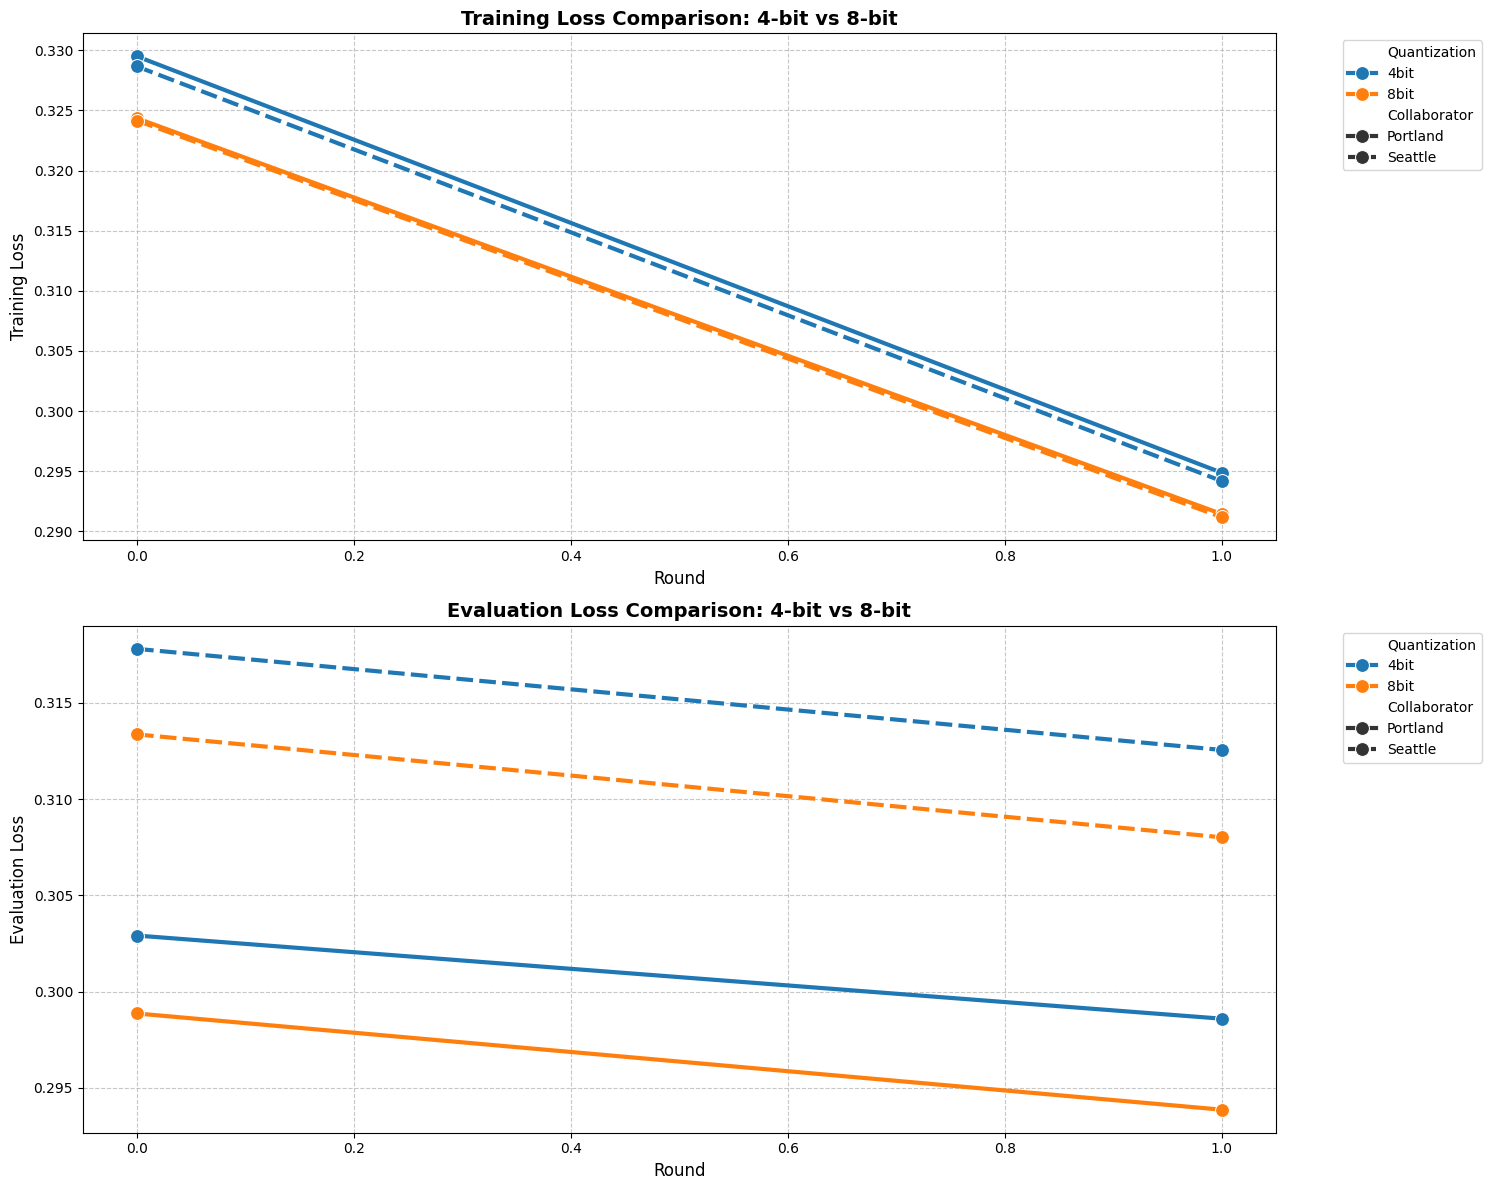

In [20]:
# Plot training loss metrics comparison between 4-bit and 8-bit
print("\n==== Training & Evaluation Loss Comparison: 4-bit vs 8-bit ====\n")
plot_loss_metrics(flflow_4bit, flflow_8bit)


==== Aggregated Performance Metrics: 4-bit vs 8-bit ====



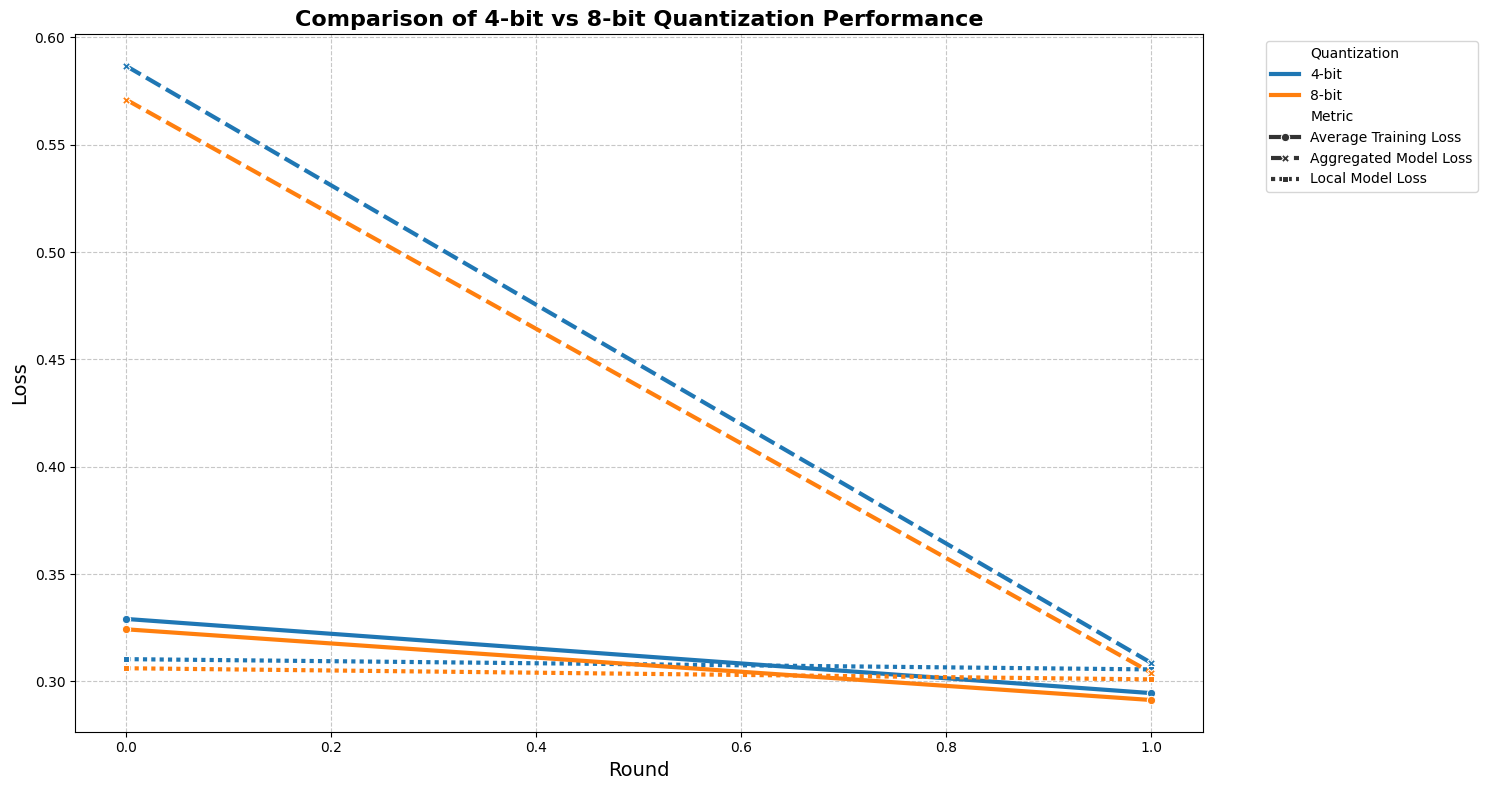

In [21]:
# Plot aggregated metrics comparison
print("\n==== Aggregated Performance Metrics: 4-bit vs 8-bit ====\n")
plot_aggregated_metrics(flflow_4bit, flflow_8bit)

### Memory Efficiency Comparison

- **4-bit Quantization**: Uses less memory overall, allowing for larger batch sizes or model sizes on the same hardware.
- **8-bit Quantization**: Requires more memory but still offers significant savings compared to full precision (FP16/FP32).
- **Peak Memory Usage**: The difference in peak memory consumption shows the trade-off between precision and memory requirements.

### Training Performance Comparison

- **Training Loss**: 8-bit quantization typically maintains closer fidelity to the original model, potentially leading to slightly better training convergence.
- **Evaluation Loss**: The evaluation metrics help determine if the higher precision of 8-bit quantization translates to better model performance.

### Use Case Recommendations

- **Resource-constrained environments**: 4-bit quantization provides better memory efficiency for edge devices or limited GPU resources.
- **Higher precision needs**: If model accuracy is critical and resources permit, 8-bit quantization offers a good balance between performance and efficiency.
- **Federated Learning Impact**: The quantization choice particularly affects resource utilization across collaborators in the federated setting.